In [4]:
import os

print(os.listdir('/content'))

['.config', 'placement_predict_50k_adjusted (1).csv', 'placement_clustering.py', 'sample_data']


In [5]:
import glob

csv_file = glob.glob('/content/*.csv')[0]

print("CSV found:", csv_file)

df = pd.read_csv(csv_file)

print("Dataset shape:", df.shape)
df.head()

CSV found: /content/placement_predict_50k_adjusted (1).csv
Dataset shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [6]:
# Keep only numeric columns for clustering
X_cluster = df.select_dtypes(include=np.number).copy()

# Remove target/label columns if present
X_cluster = X_cluster.drop(
    columns=['PlacementStatus', 'IsAnomaly'],
    errors='ignore'
)

# Fill missing values
X_cluster = X_cluster.fillna(X_cluster.median())

print("Clustering features:", X_cluster.shape)
print(X_cluster.columns.tolist())

Clustering features: (50000, 11)
['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (50000, 11)


In [8]:
k_range = range(2, 9)

inertias = []
silhouette_scores = []

# Use a sample for faster silhouette calculation
sample_size = min(5000, len(X_scaled))
sample_idx = np.random.RandomState(42).choice(
    len(X_scaled), sample_size, replace=False
)

X_sample = X_scaled[sample_idx]

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_sample, labels[sample_idx])
    )

print("K values:", list(k_range))
print("Inertias:", inertias)
print("Silhouette scores:", silhouette_scores)

K values: [2, 3, 4, 5, 6, 7, 8]
Inertias: [275589.6515574295, 204597.36494278183, 174548.3238652575, 159570.41075381843, 149333.98697859712, 142046.01337654676, 136260.19884071694]
Silhouette scores: [np.float64(0.3878026709819567), np.float64(0.2929824897319565), np.float64(0.2340720549722867), np.float64(0.19554735123637415), np.float64(0.18951101256408817), np.float64(0.16445917165189536), np.float64(0.15929578142189374)]


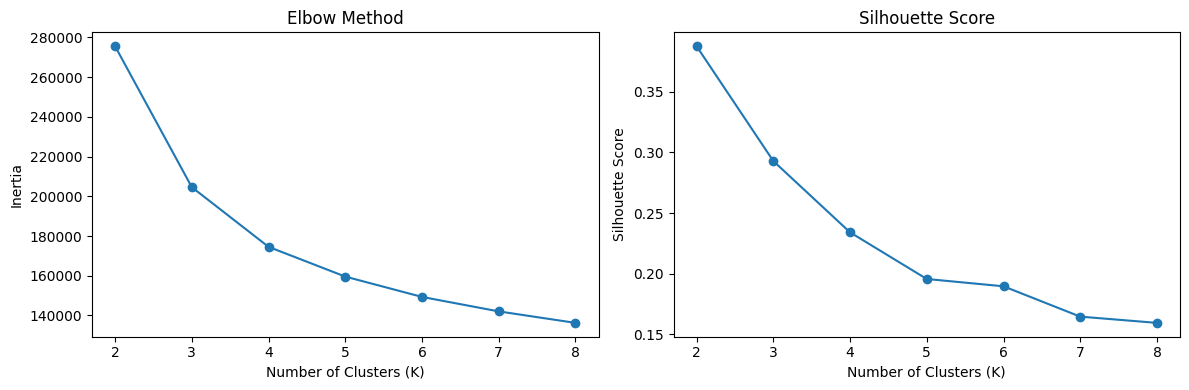

Best K by silhouette score: 2


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print("Best K by silhouette score:", best_k)

In [10]:
# Fit final K-Means using the selected K
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

final_silhouette = silhouette_score(
    X_sample,
    kmeans_labels[sample_idx]
)

print("Selected K:", best_k)
print("Final inertia:", round(kmeans_final.inertia_, 2))
print("Silhouette score:", round(final_silhouette, 4))

print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Selected K: 2
Final inertia: 275589.65
Silhouette score: 0.3878

Cluster sizes:
0    26435
1    23565
Name: count, dtype: int64


In [11]:
from sklearn.cluster import MiniBatchKMeans
import time

start = time.time()

mbk = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=256,
    n_init=10
)

mb_labels = mbk.fit_predict(X_scaled)

mb_time = time.time() - start

mb_silhouette = silhouette_score(
    X_sample,
    mb_labels[sample_idx]
)

print("MiniBatchKMeans time:", round(mb_time, 2), "seconds")
print("MiniBatchKMeans silhouette:", round(mb_silhouette, 4))

MiniBatchKMeans time: 0.02 seconds
MiniBatchKMeans silhouette: 0.3875


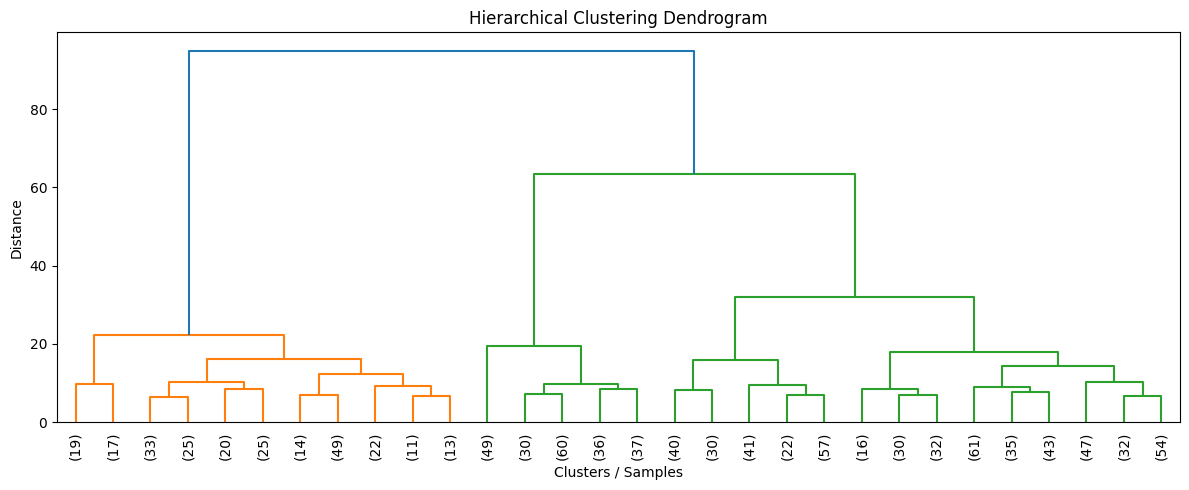

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample so the dendrogram stays readable
dendro_sample = X_scaled[:1000]

Z = linkage(dendro_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters / Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()